In [8]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [9]:
#cleaning data part 1 
import pandas as pd
df = pd.read_csv('Customer_Data.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nHead:")
print(df.head())
print("\nInfo:")
df.info()
print("\nMissing values:")
print(df.isnull().sum())

Shape: (100, 6)

Columns: ['CustomerID', 'Age', 'Orders', 'Revenue', 'City', 'Rating']

Head:
  CustomerID  Age  Orders  Revenue        City  Rating
0       C001   58       8   599289    Semarang     2.0
1       C002   26      48  5056720  Yogyakarta     1.3
2       C003   45       3   121427       Medan     1.9
3       C004   56       2   640632  Yogyakarta     2.7
4       C005   46      38  7344079     Bandung     3.8

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  100 non-null    object 
 1   Age         100 non-null    int64  
 2   Orders      100 non-null    int64  
 3   Revenue     100 non-null    int64  
 4   City        100 non-null    object 
 5   Rating      100 non-null    float64
dtypes: float64(1), int64(3), object(2)
memory usage: 4.8+ KB

Missing values:
CustomerID    0
Age           0
Orders        0
Revenue    

In [10]:
df = pd.read_csv('Customer_Data.csv', na_values=['?', 'NA', 'NaN', 'nan', 'null', 'Null', 'NULL'])

In [11]:
#cleaning data part 2

print("Duplicates:", df.duplicated().sum())
print("\nDescriptive Statistics:")
print(df.describe())
print("\nCity distribution:")
print(df['City'].value_counts())
print("\nCorrelation matrix:")
print(df[['Age', 'Orders', 'Revenue', 'Rating']].corr())

Duplicates: 0

Descriptive Statistics:
              Age      Orders       Revenue      Rating
count  100.000000  100.000000  1.000000e+02  100.000000
mean    41.530000   26.060000  6.882322e+06    2.844000
std     12.870336   15.908082  5.332424e+06    1.244975
min     18.000000    1.000000  1.214270e+05    1.000000
25%     32.000000   11.000000  2.226665e+06    1.775000
50%     42.000000   26.000000  5.698778e+06    2.700000
75%     52.000000   40.000000  1.002609e+07    3.925000
max     65.000000   50.000000  2.128285e+07    5.000000

City distribution:
City
Semarang      16
Medan         16
Surabaya      11
Yogyakarta    10
Palembang      9
Makassar       9
Depok          8
Bandung        8
Denpasar       7
Jakarta        6
Name: count, dtype: int64

Correlation matrix:
              Age    Orders   Revenue    Rating
Age      1.000000 -0.076873  0.003519 -0.181385
Orders  -0.076873  1.000000  0.747903  0.169804
Revenue  0.003519  0.747903  1.000000  0.090570
Rating  -0.181385  0.16

In [12]:
# Group by City
city_summary = df.groupby('City').agg(
    Customer_Count=('CustomerID', 'count'),
    Total_Revenue=('Revenue', 'sum'),
    Avg_Revenue=('Revenue', 'mean'),
    Avg_Orders=('Orders', 'mean'),
    Avg_Rating=('Rating', 'mean')
).reset_index().sort_values(by='Total_Revenue', ascending=False)

print("City Summary:")
print(city_summary)

# Revenue per order ratio
df['Revenue_Per_Order'] = df['Revenue'] / df['Orders']
print("\nRevenue per Order stats:")
print(df['Revenue_Per_Order'].describe())

City Summary:
         City  Customer_Count  Total_Revenue   Avg_Revenue  Avg_Orders  \
5       Medan              16      138243964  8.640248e+06   28.125000   
7    Semarang              16       91383805  5.711488e+06   23.750000   
9  Yogyakarta              10       80400222  8.040022e+06   30.400000   
0     Bandung               8       72981563  9.122695e+06   34.625000   
2       Depok               8       66496919  8.312115e+06   28.750000   
4    Makassar               9       64391033  7.154559e+06   27.555556   
1    Denpasar               7       51159609  7.308516e+06   24.285714   
8    Surabaya              11       50266625  4.569693e+06   20.181818   
6   Palembang               9       40664509  4.518279e+06   19.666667   
3     Jakarta               6       32243938  5.373990e+06   24.666667   

   Avg_Rating  
5    2.612500  
7    2.806250  
9    2.000000  
0    2.725000  
2    3.387500  
4    2.411111  
1    3.642857  
8    3.127273  
6    2.966667  
3    3.4166

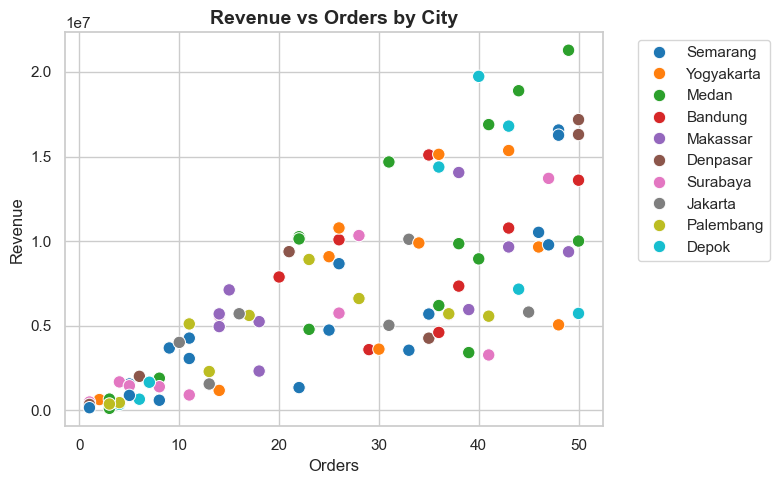

/var/folders/n4/5f0j234x5m79703ndtqxkcr00000gn/T/ipykernel_44140/3998647140.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_order, x='City', y='Total_Revenue', palette='viridis')


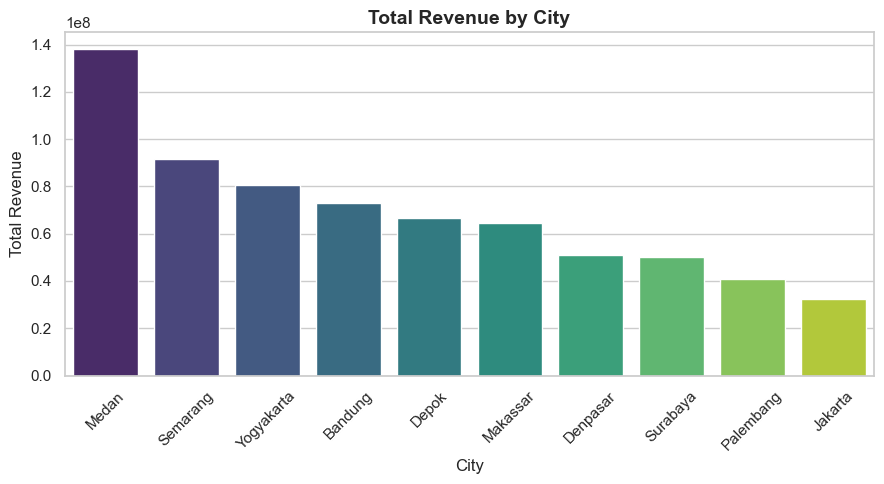

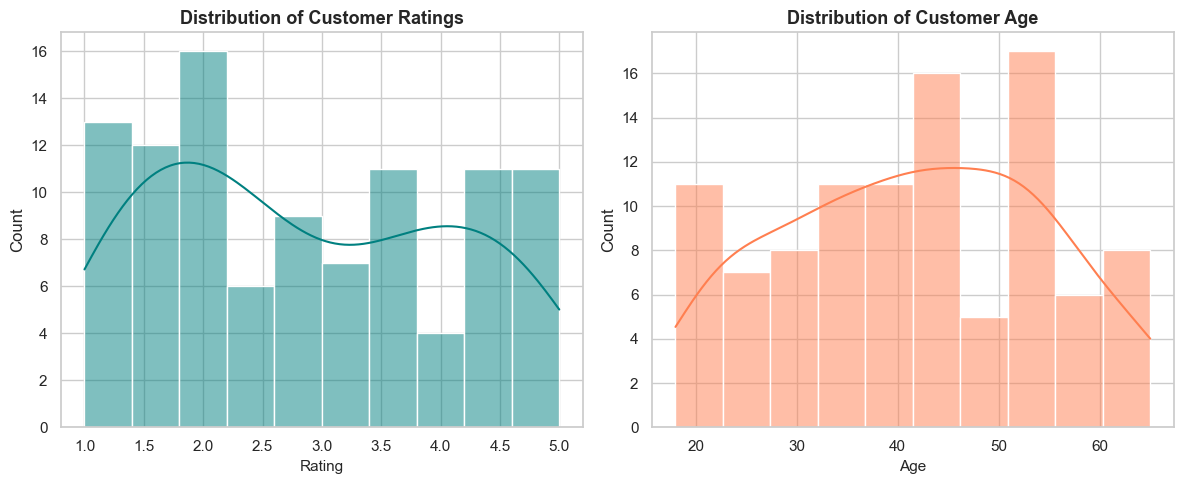

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Plot 1: Revenue vs Orders
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Orders', y='Revenue', hue='City', palette='tab10', s=80)
plt.title('Revenue vs Orders by City', fontsize=14, fontweight='bold')
plt.xlabel('Orders', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('revenue_vs_orders.png', dpi=300)
plt.show()  # Displays the figure on screen

# Plot 2: Total Revenue by City
plt.figure(figsize=(9, 5))
city_order = city_summary.sort_values(by='Total_Revenue', ascending=False)
sns.barplot(data=city_order, x='City', y='Total_Revenue', palette='viridis')
plt.title('Total Revenue by City', fontsize=14, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('revenue_by_city.png', dpi=300)
plt.show()  # Displays the figure on screen

# Plot 3: Distribution of Ratings and Age
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['Rating'], bins=10, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Customer Ratings', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating', fontsize=11)

sns.histplot(df['Age'], bins=10, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribution of Customer Age', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age', fontsize=11)

plt.tight_layout()
plt.savefig('distributions.png', dpi=300)
plt.show()  # Displays the figure on screen

In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv('Customer_Data.csv')
print(df.head())
print(df.shape)

  CustomerID  Age  Orders  Revenue        City  Rating
0       C001   58       8   599289    Semarang     2.0
1       C002   26      48  5056720  Yogyakarta     1.3
2       C003   45       3   121427       Medan     1.9
3       C004   56       2   640632  Yogyakarta     2.7
4       C005   46      38  7344079     Bandung     3.8
(100, 6)


In [16]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Feature engineering for processed dataset
df_clean = df.copy()
df_clean['Revenue_Per_Order'] = (df_clean['Revenue'] / df_clean['Orders']).round(2)
# Age brackets
bins = [17, 30, 45, 66]
labels = ['Young Adult (18-30)', 'Middle-Aged (31-45)', 'Mature (46-65)']
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=bins, labels=labels)

# Save processed clean version
df_clean.to_csv('Customer_Data_Cleaned.csv', index=False)
print("Saved Customer_Data_Cleaned.csv")

# ML Modeling
X = df[['Age', 'Orders', 'Rating', 'City']]
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', ['Age', 'Orders', 'Rating']),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['City'])
    ]
)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results[name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'Pipeline': pipe, 'Predictions': preds}
    print(f"{name} -> R2: {r2:.4f}, MAE: {mae:,.2f}, RMSE: {rmse:,.2f}")

Saved Customer_Data_Cleaned.csv
Linear Regression -> R2: 0.1835, MAE: 4,007,085.66, RMSE: 4,683,013.06
Ridge Regression -> R2: 0.2416, MAE: 3,821,966.15, RMSE: 4,513,585.75
Random Forest -> R2: 0.4297, MAE: 2,760,351.70, RMSE: 3,913,873.03
Gradient Boosting -> R2: 0.1020, MAE: 3,382,144.45, RMSE: 4,911,262.16


Feature Importances:
            Feature  Importance
1            Orders    0.675612
2            Rating    0.112841
0               Age    0.109549
4        City_Depok    0.023504
7        City_Medan    0.017150
9     City_Semarang    0.016589
11  City_Yogyakarta    0.012372
8    City_Palembang    0.008086
5      City_Jakarta    0.006997
3     City_Denpasar    0.006207
10    City_Surabaya    0.005697
6     City_Makassar    0.005398


/var/folders/n4/5f0j234x5m79703ndtqxkcr00000gn/T/ipykernel_44140/2400670048.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


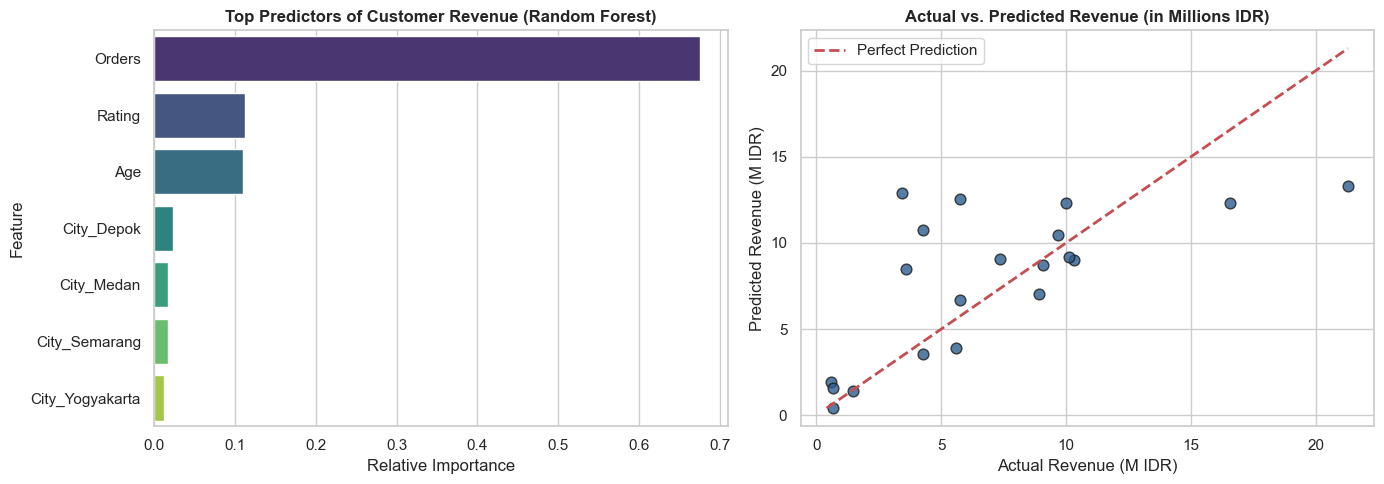

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

best_rf = results['Random Forest']['Pipeline']
rf_model = best_rf.named_steps['model']
prep = best_rf.named_steps['prep']

# Feature names
cat_cols = (
    prep.named_transformers_['cat'].get_feature_names_out(['City']).tolist()
)
all_features = ['Age', 'Orders', 'Rating'] + cat_cols

importances = rf_model.feature_importances_
feat_df = pd.DataFrame(
    {'Feature': all_features, 'Importance': importances}
).sort_values(by='Importance', ascending=False)
print('Feature Importances:')
print(feat_df)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Feature Importances
sns.barplot(
    data=feat_df.head(7), x='Importance', y='Feature', ax=axes[0], palette='viridis'
)
axes[0].set_title(
    'Top Predictors of Customer Revenue (Random Forest)',
    fontsize=12,
    fontweight='bold',
)
axes[0].set_xlabel('Relative Importance')

# Plot 2: Actual vs Predicted Revenue
preds = results['Random Forest']['Predictions']
axes[1].scatter(
    y_test / 1e6, preds / 1e6, color='#2b5c8f', s=60, alpha=0.8, edgecolors='k'
)
min_val = min(y_test.min(), preds.min()) / 1e6
max_val = max(y_test.max(), preds.max()) / 1e6
axes[1].plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    lw=2,
    label='Perfect Prediction',
)
axes[1].set_title(
    'Actual vs. Predicted Revenue (in Millions IDR)',
    fontsize=12,
    fontweight='bold',
)
axes[1].set_xlabel('Actual Revenue (M IDR)')
axes[1].set_ylabel('Predicted Revenue (M IDR)')
axes[1].legend()

plt.tight_layout()

# 1. Save the file first if you still want the PNG on disk
plt.savefig('ml_model_evaluation.png', dpi=300)

# 2. Render the plot to the screen
plt.show()

# 3. Free up memory only after showing the figure
plt.close()

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('Customer_Data.csv')
print(df['Rating'].describe())
print(df['Rating'].head(10))

count    100.000000
mean       2.844000
std        1.244975
min        1.000000
25%        1.775000
50%        2.700000
75%        3.925000
max        5.000000
Name: Rating, dtype: float64
0    2.0
1    1.3
2    1.9
3    2.7
4    3.8
5    1.4
6    2.1
7    4.9
8    4.5
9    1.2
Name: Rating, dtype: float64


In [2]:
# Check distribution across thresholds
print("Rating >= 4.0 count:", (df['Rating'] >= 4.0).sum())
print("Rating 3.0 to < 4.0 count:", ((df['Rating'] >= 3.0) & (df['Rating'] < 4.0)).sum())
print("Rating < 3.0 count:", (df['Rating'] < 3.0).sum())

# Let's check city-by-city CSAT and NPS
def calculate_metrics(data, promoter_thresh=4.0, passive_thresh=3.0):
    csat = (data['Rating'] >= 4.0).mean() * 100
    promoters = (data['Rating'] >= promoter_thresh).mean() * 100
    detractors = (data['Rating'] < passive_thresh).mean() * 100
    nps = promoters - detractors
    return pd.Series({
        'Avg_Rating': data['Rating'].mean(),
        'CSAT_Pct': csat,
        'Promoters_Pct': promoters,
        'Passives_Pct': ((data['Rating'] >= passive_thresh) & (data['Rating'] < promoter_thresh)).mean() * 100,
        'Detractors_Pct': detractors,
        'NPS': nps
    })

overall_metrics = calculate_metrics(df)
print("Overall Metrics:")
print(overall_metrics)

city_metrics = df.groupby('City').apply(calculate_metrics).reset_index()
print("\nCity Metrics:")
print(city_metrics.sort_values(by='NPS', ascending=False))

Rating >= 4.0 count: 25
Rating 3.0 to < 4.0 count: 19
Rating < 3.0 count: 56
Overall Metrics:
Avg_Rating         2.844
CSAT_Pct          25.000
Promoters_Pct     25.000
Passives_Pct      19.000
Detractors_Pct    56.000
NPS              -31.000
dtype: float64

City Metrics:
         City  Avg_Rating   CSAT_Pct  Promoters_Pct  Passives_Pct  \
1    Denpasar    3.642857  57.142857      57.142857     14.285714   
3     Jakarta    3.416667  50.000000      50.000000     16.666667   
2       Depok    3.387500  50.000000      50.000000     12.500000   
8    Surabaya    3.127273  36.363636      36.363636     18.181818   
6   Palembang    2.966667  22.222222      22.222222     33.333333   
7    Semarang    2.806250  18.750000      18.750000     25.000000   
0     Bandung    2.725000  12.500000      12.500000     25.000000   
5       Medan    2.612500  12.500000      12.500000     25.000000   
4    Makassar    2.411111  11.111111      11.111111     11.111111   
9  Yogyakarta    2.000000  10.000000

/var/folders/n4/5f0j234x5m79703ndtqxkcr00000gn/T/ipykernel_2701/3202433714.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  city_metrics = df.groupby('City').apply(calculate_metrics).reset_index()


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Let's create an insightful chart visualizing CSAT and NPS by City
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

city_metrics_sorted = city_metrics.sort_values(by='NPS', ascending=True)

# Plot 1: NPS by City (Horizontal Bar)
colors = ['#d9534f' if x < 0 else '#5cb85c' for x in city_metrics_sorted['NPS']]
bars = axes[0].barh(city_metrics_sorted['City'], city_metrics_sorted['NPS'], color=colors, edgecolor='black', alpha=0.85)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Net Promoter Score (NPS) by City', fontsize=13, fontweight='bold')
axes[0].set_xlabel('NPS Score (-100 to +100)', fontsize=11)
for bar in bars:
    width = bar.get_width()
    offset = 2 if width >= 0 else -6
    axes[0].text(width + offset, bar.get_y() + bar.get_height()/2, f"{width:.1f}", 
                 va='center', fontsize=9, fontweight='bold')

# Plot 2: Customer Sentiment Cohorts Stacked Bar (% Detractors, Passives, Promoters)
cohort_data = city_metrics.sort_values(by='Promoters_Pct', ascending=False).set_index('City')[['Detractors_Pct', 'Passives_Pct', 'Promoters_Pct']]
cohort_data.plot(kind='bar', stacked=True, color=['#e74c3c', '#f39c12', '#2ecc71'], ax=axes[1], edgecolor='black', alpha=0.9)
axes[1].set_title('Customer Sentiment Cohorts (% Detractor / Passive / Promoter)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].set_xlabel('City', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(['Detractors (< 3.0)', 'Passives (3.0 - 3.9)', 'Promoters (>= 4.0)'], loc='upper right')

plt.tight_layout()
plt.savefig('csat_nps_analysis.png', dpi=300)
plt.close()
print("CSAT & NPS visualization saved.")

CSAT & NPS visualization saved.


OVERALL CUSTOMER SATISFACTION & ADVOCACY METRICS
Total Customers   : 100
Mean Rating       : 2.84 / 5.00
CSAT (% >= 4.0)   : 25.0%
Promoters (% >=4) : 25.0%
Passives (3.0-3.9): 19.0%
Detractors (< 3.0): 56.0%
Net Promoter Score: -31.0

CITY-LEVEL BREAKDOWN:
      City  Customer_Count  Avg_Rating  CSAT_Pct  Promoters_Pct  Passives_Pct  Detractors_Pct   NPS
  Denpasar             7.0        3.64      57.1           57.1          14.3            28.6  28.6
   Jakarta             6.0        3.42      50.0           50.0          16.7            33.3  16.7
     Depok             8.0        3.39      50.0           50.0          12.5            37.5  12.5
  Surabaya            11.0        3.13      36.4           36.4          18.2            45.5  -9.1
 Palembang             9.0        2.97      22.2           22.2          33.3            44.4 -22.2
  Semarang            16.0        2.81      18.8           18.8          25.0            56.2 -37.5
   Bandung             8.0        2.72    

/var/folders/n4/5f0j234x5m79703ndtqxkcr00000gn/T/ipykernel_2701/588129100.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_city_metrics)


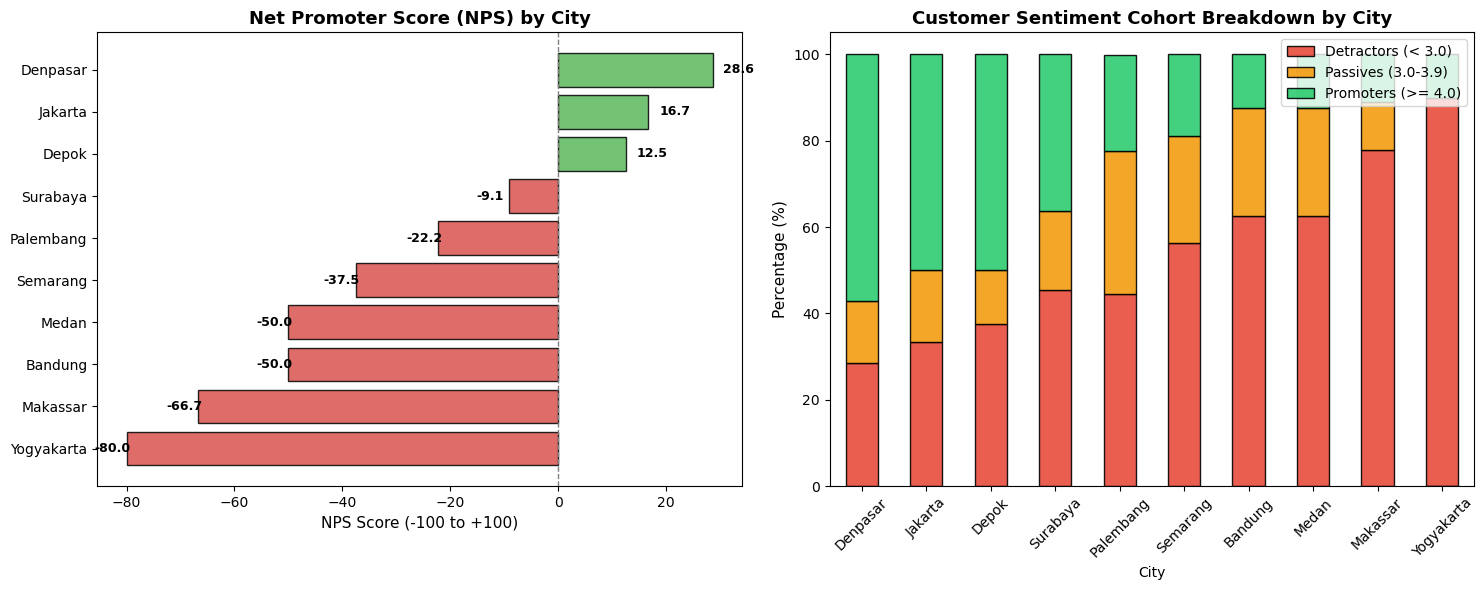

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load Data
df = pd.read_csv('Customer_Data.csv')


# 2. Assign Sentiment Cohorts
def assign_cohort(rating):
  if rating >= 4.0:
    return 'Promoter'
  elif rating >= 3.0:
    return 'Passive'
  else:
    return 'Detractor'


df['Sentiment_Cohort'] = df['Rating'].apply(assign_cohort)

# 3. Overall CSAT & NPS Calculation
total_customers = len(df)
promoters = (df['Sentiment_Cohort'] == 'Promoter').sum()
passives = (df['Sentiment_Cohort'] == 'Passive').sum()
detractors = (df['Sentiment_Cohort'] == 'Detractor').sum()

csat_score = (promoters / total_customers) * 100
nps_score = ((promoters - detractors) / total_customers) * 100

print("=" * 45)
print("OVERALL CUSTOMER SATISFACTION & ADVOCACY METRICS")
print("=" * 45)
print(f'Total Customers   : {total_customers}')
print(f"Mean Rating       : {df['Rating'].mean():.2f} / 5.00")
print(f'CSAT (% >= 4.0)   : {csat_score:.1f}%')
print(f'Promoters (% >=4) : {(promoters / total_customers) * 100:.1f}%')
print(f'Passives (3.0-3.9): {(passives / total_customers) * 100:.1f}%')
print(f'Detractors (< 3.0): {(detractors / total_customers) * 100:.1f}%')
print(f'Net Promoter Score: {nps_score:.1f}')
print('=' * 45)


# 4. Regional Breakdown Function
def calculate_city_metrics(group):
  n = len(group)
  p = (group['Sentiment_Cohort'] == 'Promoter').sum()
  pas = (group['Sentiment_Cohort'] == 'Passive').sum()
  d = (group['Sentiment_Cohort'] == 'Detractor').sum()
  return pd.Series({
      'Customer_Count': n,
      'Avg_Rating': round(group['Rating'].mean(), 2),
      'CSAT_Pct': round((p / n) * 100, 1),
      'Promoters_Pct': round((p / n) * 100, 1),
      'Passives_Pct': round((pas / n) * 100, 1),
      'Detractors_Pct': round((d / n) * 100, 1),
      'NPS': round(((p - d) / n) * 100, 1),
  })


city_analysis = (
    df.groupby('City')
    .apply(calculate_city_metrics)
    .reset_index()
    .sort_values(by='NPS', ascending=False)
)

print('\nCITY-LEVEL BREAKDOWN:')
print(city_analysis.to_string(index=False))

# 5. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot A: NPS by City (Horizontal Diverging Bar Chart)
city_sorted = city_analysis.sort_values(by='NPS', ascending=True)
colors = ['#d9534f' if x < 0 else '#5cb85c' for x in city_sorted['NPS']]
bars = axes[0].barh(
    city_sorted['City'],
    city_sorted['NPS'],
    color=colors,
    edgecolor='black',
    alpha=0.85,
)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Net Promoter Score (NPS) by City', fontsize=13, weight='bold')
axes[0].set_xlabel('NPS Score (-100 to +100)', fontsize=11)

for bar in bars:
  w = bar.get_width()
  offset = 2 if w >= 0 else -6
  axes[0].text(
      w + offset,
      bar.get_y() + bar.get_height() / 2,
      f'{w:.1f}',
      va='center',
      fontsize=9,
      fontweight='bold',
  )

# Plot B: Stacked Sentiment Composition
cohort_cols = ['Detractors_Pct', 'Passives_Pct', 'Promoters_Pct']
stacked_data = city_analysis.set_index('City')[cohort_cols]
stacked_data.plot(
    kind='bar',
    stacked=True,
    color=['#e74c3c', '#f39c12', '#2ecc71'],
    ax=axes[1],
    edgecolor='black',
    alpha=0.9,
)
axes[1].set_title(
    'Customer Sentiment Cohort Breakdown by City', fontsize=13, weight='bold'
)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(
    ['Detractors (< 3.0)', 'Passives (3.0-3.9)', 'Promoters (>= 4.0)'],
    loc='upper right',
)

plt.tight_layout()
plt.savefig('csat_nps_analysis.png', dpi=300)
plt.show()  # Renders the figure to the screen
plt.close()